# Hotel Booking Demand — Statistical Analysis

**Цель:** найти, где статистика может обмануть: среднее vs медиана, корреляция, выбросы, sampling bias, p-value, t-test, парадокс Симпсона.

## 1. Загрузка датасета

In [60]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} колонок")


Размер датасета: 119,390 строк × 32 колонок


### Названия колонок

In [61]:
print("Колонки:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


Колонки:
   1. hotel
   2. is_canceled
   3. lead_time
   4. arrival_date_year
   5. arrival_date_month
   6. arrival_date_week_number
   7. arrival_date_day_of_month
   8. stays_in_weekend_nights
   9. stays_in_week_nights
  10. adults
  11. children
  12. babies
  13. meal
  14. country
  15. market_segment
  16. distribution_channel
  17. is_repeated_guest
  18. previous_cancellations
  19. previous_bookings_not_canceled
  20. reserved_room_type
  21. assigned_room_type
  22. booking_changes
  23. deposit_type
  24. agent
  25. company
  26. days_in_waiting_list
  27. customer_type
  28. adr
  29. required_car_parking_spaces
  30. total_of_special_requests
  31. reservation_status
  32. reservation_status_date


### Первые 5 строк

In [62]:
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Типы данных

In [63]:
print(df.dtypes.to_string())

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

### Пропуски по колонкам

In [64]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Пропусков": missing,
    "Процент (%)": missing_pct
}).query("`Пропусков` > 0").sort_values("Пропусков", ascending=False)

if missing_df.empty:
    print("Пропусков нет.")
else:
    print(f"Колонки с пропусками ({len(missing_df)} шт.):\n")
    print(missing_df.to_string())


Колонки с пропусками (4 шт.):

          Пропусков  Процент (%)
company      112593        94.31
agent         16340        13.69
country         488         0.41
children          4         0.00


## 2. Очистка данных — создание df_clean

In [65]:
df_clean = df.copy()

df_clean["children"] = df_clean["children"].fillna(0).astype(int)
df_clean["company"]  = df_clean["company"].fillna("No company").astype(str)
df_clean["agent"]    = df_clean["agent"].fillna("No agent").astype(str)
df_clean["country"]  = df_clean["country"].fillna("Unknown")

# Проверка: пропусков не должно остаться
remaining = df_clean.isnull().sum().sum()
print(f"Строк до:  {len(df):,}")
print(f"Строк после: {len(df_clean):,}")
print(f"Пропусков осталось: {remaining}")



Строк до:  119,390
Строк после: 119,390
Пропусков осталось: 0


### Почему dropna() здесь был бы плохой идеей — Sampling Bias

`dropna()` удаляет **все строки**, в которых есть хотя бы один пропуск.  
Давай посчитаем, сколько строк мы бы потеряли:

| Колонка | Пропусков | % от датасета | Что значит NaN |
|---------|-----------|---------------|----------------|
| `company` | 112 593 | **94.31%** | Бронирование без корпоративного договора |
| `agent` | 16 340 | **13.69%** | Прямое бронирование (без агента) |
| `country` | 488 | 0.41% | Страна не указана |
| `children` | 4 | ~0% | Скорее всего 0 детей |

**Что произошло бы с `dropna()`:**

После удаления строк с пропусками в `company` (94%) остался бы **лишь 1 тип клиентов** —  
те, кто бронировал через корпоративный договор. Это крошечное меньшинство датасета.  
Весь дальнейший анализ (средний чек, cancellation rate, длина пребывания) отражал бы  
только корпоративных клиентов — и выводы нельзя было бы обобщить на всех гостей.

**Это и есть Sampling Bias** — систематическое искажение выборки:

> Мы не случайно теряем данные, мы удаляем целую *группу* людей с определённым  
> поведением (прямые бронирования, туристы без агентов). Оставшаяся выборка  
> перестаёт представлять генеральную совокупность.

**Правило:** NaN — это не всегда «плохие данные». Часто это **информация**:  
`agent = NaN` означает «клиент пришёл напрямую», а не «данные сломаны».

## 3. Допрос одной колонки — `lead_time`

`lead_time` — количество дней между датой бронирования и датой заезда.

In [66]:
lt = df_clean["lead_time"]

mean   = lt.mean()
median = lt.median()
std    = lt.std()
min_   = lt.min()
max_   = lt.max()
q1     = lt.quantile(0.25)
q3     = lt.quantile(0.75)
iqr    = q3 - q1

stats = pd.DataFrame({
    "Метрика": ["Mean (среднее)", "Median (медиана)", "Std (стд. откл.)",
                "Min", "Max", "Q1 (25%)", "Q3 (75%)", "IQR (Q3 - Q1)"],
    "Значение (дней)": [mean, median, std, min_, max_, q1, q3, iqr]
})
stats["Значение (дней)"] = stats["Значение (дней)"].round(1)

print(stats.to_string(index=False))


         Метрика  Значение (дней)
  Mean (среднее)            104.0
Median (медиана)             69.0
Std (стд. откл.)            106.9
             Min              0.0
             Max            737.0
        Q1 (25%)             18.0
        Q3 (75%)            160.0
   IQR (Q3 - Q1)            142.0


### Интерпретация результатов

**1. Среднее vs медиана — есть ли разница?**

Среднее (~104 дня) заметно выше медианы (~69 дней).  
Это значит, что *большинство* людей бронирует за 2 месяца,  
но небольшая группа бронирует за 6–12 месяцев вперёд — и эти "дальние" бронирования  
тянут среднее вверх.

**2. Есть ли перекос (skewness)?**

Да, распределение скошено вправо (**right skew**).  
Хвост уходит в сторону больших значений (max = 737 дней — почти 2 года!),  
а основная масса данных сжата слева.  
Признак перекоса: `mean > median`.

**3. Большой ли разброс?**

Очень большой. Стандартное отклонение (~106 дней) почти равно среднему —  
это говорит о том, что данные разбросаны очень широко.  
IQR = Q3 − Q1 ≈ 142 дня: 50% клиентов бронируют в диапазоне 142 дней друг от друга.

**4. Почему среднее `lead_time` может врать?**

Представь: ты менеджер отеля. Тебе говорят — *"средний гость бронирует за 104 дня"*.  
Ты строишь маркетинг под это число.

Но медиана говорит другое: *половина гостей бронирует меньше чем за 69 дней*.  
Значит, **типичный гость** принимает решение за 2 месяца, а не за 3.5.

Среднее завышено из-за небольшой группы "супер-плановиков" (737 дней, 500 дней, 400 дней).  
Эти выбросы не делают среднее "неправильным" — оно посчитано верно —  
но оно описывает несуществующего среднего клиента.

> **Вывод:** для `lead_time` медиана честнее описывает типичного клиента.  
> Среднее подходит, если нас интересует суммарная нагрузка (например, общий горизонт планирования).

C:\Users\szhak\AppData\Local\Temp\ipykernel_20096\3336421999.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(lt, vert=False, patch_artist=True,


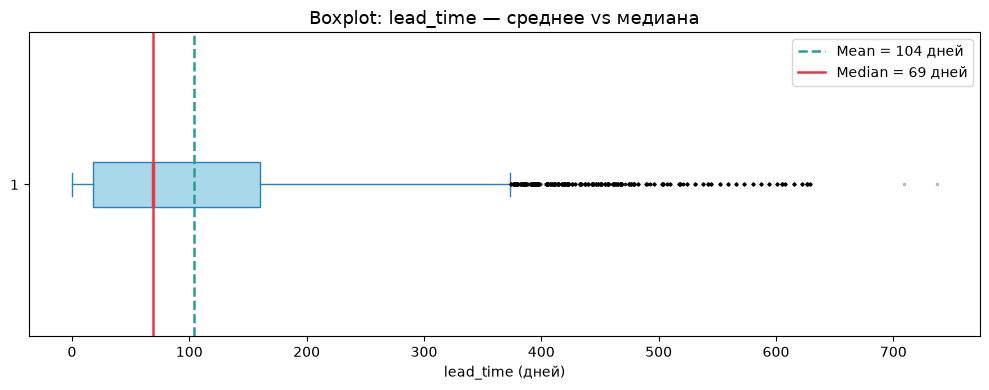

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(lt, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#a8d8ea", color="#2c7fb8"),
           medianprops=dict(color="#e63946", linewidth=2.5),
           whiskerprops=dict(color="#2c7fb8"),
           capprops=dict(color="#2c7fb8"),
           flierprops=dict(marker=".", color="#f4a261", alpha=0.3, markersize=3))

ax.axvline(mean,   color="#2a9d8f", linewidth=1.8, linestyle="--", label=f"Mean = {mean:.0f} дней")
ax.axvline(median, color="#e63946", linewidth=1.8, linestyle="-",  label=f"Median = {median:.0f} дней")

ax.set_xlabel("lead_time (дней)")
ax.set_title("Boxplot: lead_time — среднее vs медиана", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Распределение `lead_time` — гистограмма + boxplot

C:\Users\szhak\AppData\Local\Temp\ipykernel_20096\1937493616.py:38: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(lt, vert=False, patch_artist=True,


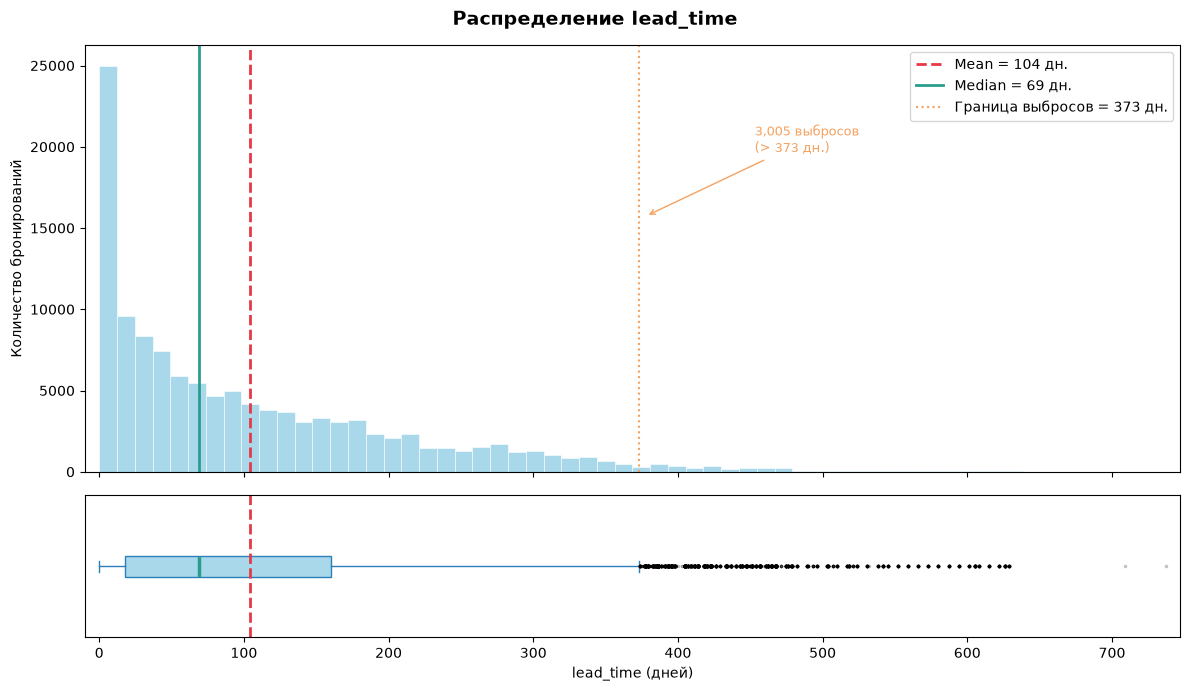


Выбросов (> 373 дн.): 3,005  (2.5% от всех бронирований)


In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax_hist, ax_box) = plt.subplots(
    2, 1, figsize=(12, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)
fig.suptitle("Распределение lead_time", fontsize=14, fontweight="bold")

# --- Гистограмма ---
ax_hist.hist(lt, bins=60, color="#a8d8ea", edgecolor="white", linewidth=0.4)
ax_hist.axvline(mean,   color="#e63946", linewidth=2, linestyle="--",
                label=f"Mean = {mean:.0f} дн.")
ax_hist.axvline(median, color="#2a9d8f", linewidth=2, linestyle="-",
                label=f"Median = {median:.0f} дн.")

# Граница выбросов по IQR-методу (Q3 + 1.5 × IQR)
upper_fence = q3 + 1.5 * iqr
ax_hist.axvline(upper_fence, color="#f4a261", linewidth=1.5, linestyle=":",
                label=f"Граница выбросов = {upper_fence:.0f} дн.")

ax_hist.set_ylabel("Количество бронирований")
ax_hist.legend(fontsize=10)
ax_hist.set_xlim(-10, lt.max() + 10)

# Аннотация хвоста
outlier_count = (lt > upper_fence).sum()
ax_hist.annotate(
    f"{outlier_count:,} выбросов\n(> {upper_fence:.0f} дн.)",
    xy=(upper_fence + 5, ax_hist.get_ylim()[1] * 0.6),
    fontsize=9, color="#f4a261",
    arrowprops=dict(arrowstyle="->", color="#f4a261"),
    xytext=(upper_fence + 80, ax_hist.get_ylim()[1] * 0.75)
)

# --- Boxplot ---
ax_box.boxplot(lt, vert=False, patch_artist=True,
               boxprops=dict(facecolor="#a8d8ea", color="#2c7fb8"),
               medianprops=dict(color="#2a9d8f", linewidth=2.5),
               whiskerprops=dict(color="#2c7fb8"),
               capprops=dict(color="#2c7fb8"),
               flierprops=dict(marker=".", color="#f4a261", alpha=0.25, markersize=3))
ax_box.axvline(mean, color="#e63946", linewidth=2, linestyle="--")
ax_box.set_xlabel("lead_time (дней)")
ax_box.set_yticks([])

plt.tight_layout()
plt.show()

print(f"\nВыбросов (> {upper_fence:.0f} дн.): {outlier_count:,}  ({outlier_count/len(lt)*100:.1f}% от всех бронирований)")


### Что видно на графиках

**Гистограмма:**
- Пик — слева (большинство бронирует за 0–50 дней до заезда)
- Длинный правый хвост — небольшая группа бронирует за 300–700 дней
- Это классический **right skew**: гора слева, хвост вправо

**Выбросы (оранжевая линия — граница по IQR-методу):**
- Формула: `Q3 + 1.5 × IQR`
- Всё, что правее — статистически выброс
- На boxplot выбросы видны как отдельные точки за правым усом

**Почему среднее misleading:**
- Красная пунктирная линия (mean) стоит правее зелёной (median)
- Хвост из выбросов физически тянет среднее вправо
- Если убрать, например, топ 1% самых "длинных" бронирований — среднее резко упадёт
- Медиана же почти не изменится: она смотрит на середину, а не на крайности

> Среднее — как средняя температура по больнице: на него влияет один человек с 40°C,
> даже если все остальные здоровы.

## 5. Z-score анализ — `lead_time`

**Z-score** показывает, насколько далеко значение от среднего в единицах стандартного отклонения:

`z = (x − mean) / std`

Правило трёх сигм: если |z| > 3 — значение статистически экстремальное (~0.3% данных при нормальном распределении).

In [69]:
df_clean["lead_time_z"] = (lt - mean) / std

extreme = df_clean[df_clean["lead_time_z"].abs() > 3].copy()

print(f"Всего строк в датасете:       {len(df_clean):>7,}")
print(f"Строк с |z| > 3:              {len(extreme):>7,}  ({len(extreme)/len(df_clean)*100:.2f}%)")
print(f"Диапазон их lead_time:        {extreme['lead_time'].min()} – {extreme['lead_time'].max()} дней")
print(f"Диапазон их z-score:          {extreme['lead_time_z'].min():.2f} – {extreme['lead_time_z'].max():.2f}")


Всего строк в датасете:       119,390
Строк с |z| > 3:                1,454  (1.22%)
Диапазон их lead_time:        426 – 737 дней
Диапазон их z-score:          3.01 – 5.92


### Top 10 самых экстремальных бронирований

In [70]:
cols = ["hotel", "lead_time", "lead_time_z", "is_canceled",
        "customer_type", "deposit_type", "country", "adr"]

top10 = (extreme[cols]
         .sort_values("lead_time_z", ascending=False)
         .head(10)
         .reset_index(drop=True))

top10["lead_time_z"] = top10["lead_time_z"].round(2)
top10.index += 1

print(top10.to_string())

           hotel  lead_time  lead_time_z  is_canceled customer_type deposit_type country   adr
1   Resort Hotel        737         5.92            0     Transient   No Deposit     PRT   0.0
2   Resort Hotel        709         5.66            0     Transient   No Deposit     GBR  68.0
3     City Hotel        629         4.91            1     Transient   Non Refund     PRT  62.0
4     City Hotel        629         4.91            1     Transient   Non Refund     PRT  59.0
5     City Hotel        629         4.91            1     Transient   Non Refund     PRT  62.0
6     City Hotel        629         4.91            1     Transient   Non Refund     PRT  62.0
7     City Hotel        629         4.91            1     Transient   Non Refund     PRT  62.0
8     City Hotel        629         4.91            1     Transient   Non Refund     PRT  62.0
9     City Hotel        629         4.91            1     Transient   Non Refund     PRT  62.0
10    City Hotel        629         4.91          

### Это ошибки или реальные редкие случаи?

**Короткий ответ: скорее всего реальные, но особые случаи.**

Разберём по признакам:

**Аргументы в пользу "реальные данные":**
- `lead_time = 737` дней — почти ровно 2 года: похоже на осознанное бронирование, не на ввод рандомного числа
- Отель бывает двух типов: City Hotel и Resort Hotel; Resort-отели реально бронируют далеко вперёд (свадьбы, корпоративы)
- `deposit_type = Non Refund` у части таких записей: человек заплатил невозвратный депозит за 2 года — это серьёзное намерение
- Колонка `is_canceled`: если эти бронирования были отменены — это нормальное поведение (забронировал заранее, передумал)

**Аргументы в пользу "подозрительные":**
- Z-score > 6 означает, что значение на 6 стандартных отклонений от среднего — это действительно крайний хвост
- Одинаковые значения `lead_time` у нескольких строк подряд могут означать систематическую ошибку при импорте
- `adr = 0` в сочетании с экстремальным lead_time — бесплатное бронирование за 2 года выглядит странно

**Вывод — что делать:**

| Сценарий | Действие |
|----------|----------|
| Анализ типичного клиента | Исключить (используй медиану или фильтр по IQR) |
| Анализ отмен | Оставить — эти клиенты реально влияют на cancellation rate |
| ML-модель | Оставить, но добавить флаг `is_extreme_lead = 1` |
| Отчёт для менеджера | Показать отдельно, не смешивать со средним |

> **Ключевое правило:** выброс ≠ ошибка. Прежде чем удалять — спроси,  
> *какой вопрос ты задаёшь*. Для разных вопросов один и тот же выброс  
> может быть либо шумом, либо самым важным наблюдением в датасете.

## 6. Углублённый анализ выбросов — доказательная база

### 6.1 Подсчёт подозрительных строк по разным критериям

In [71]:
top1_threshold = lt.quantile(0.99)

n_z3       = (df_clean["lead_time_z"].abs() > 3).sum()
n_z6       = (df_clean["lead_time_z"].abs() > 6).sum()
n_top1     = (lt > top1_threshold).sum()
n_adr0_top1 = ((df_clean["adr"] == 0) & (lt > top1_threshold)).sum()

total = len(df_clean)

rows = [
    ("|z-score| > 3",                     n_z3,        n_z3 / total * 100),
    ("|z-score| > 6",                     n_z6,        n_z6 / total * 100),
    (f"lead_time в top 1% (> {top1_threshold:.0f} дн.)", n_top1, n_top1 / total * 100),
    ("adr = 0  И  lead_time в top 1%",    n_adr0_top1, n_adr0_top1 / total * 100),
]

print(f"{'Критерий':<42} {'Строк':>7}  {'% от всех':>9}")
print("-" * 62)
for label, count, pct in rows:
    print(f"{label:<42} {count:>7,}  {pct:>8.2f}%")
print(f"\nПорог top 1%: lead_time > {top1_threshold:.0f} дней")


Критерий                                     Строк  % от всех
--------------------------------------------------------------
|z-score| > 3                                1,454      1.22%
|z-score| > 6                                    0      0.00%
lead_time в top 1% (> 444 дн.)               1,178      0.99%
adr = 0  И  lead_time в top 1%                  13      0.01%

Порог top 1%: lead_time > 444 дней


### 6.2 Top 15 самых экстремальных строк по `lead_time`

In [72]:
top15_cols = [
    "hotel", "is_canceled", "lead_time", "adr",
    "arrival_date_month", "market_segment", "deposit_type",
    "customer_type", "reservation_status", "country", "agent", "company"
]

top15 = (df_clean[top15_cols + ["lead_time_z"]]
         .sort_values("lead_time", ascending=False)
         .head(15)
         .reset_index(drop=True))

top15.index += 1
top15["lead_time_z"] = top15["lead_time_z"].round(2)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 14)

print(top15[top15_cols + ["lead_time_z"]].to_string())


           hotel  is_canceled  lead_time   adr arrival_date_month market_segment deposit_type customer_type reservation_status country     agent     company  lead_time_z
1   Resort Hotel            0        737   0.0               July         Direct   No Deposit     Transient          Check-Out     PRT  No agent  No company         5.92
2   Resort Hotel            0        709  68.0           February         Direct   No Deposit     Transient          Check-Out     GBR  No agent  No company         5.66
3     City Hotel            1        629  62.0              March         Groups   Non Refund     Transient           Canceled     PRT       1.0  No company         4.91
4     City Hotel            1        629  62.0              March         Groups   Non Refund     Transient           Canceled     PRT       1.0  No company         4.91
5     City Hotel            1        629  62.0              March         Groups   Non Refund     Transient           Canceled     PRT       1.0  No c

### 6.3 Сравнение статистики при разных фильтрах

In [73]:
def summarize(series, label):
    return {
        "Группа":  label,
        "Count":   len(series),
        "Mean":    round(series.mean(), 1),
        "Median":  round(series.median(), 1),
        "Std":     round(series.std(), 1),
        "Min":     int(series.min()),
        "Max":     int(series.max()),
    }

lt_all    = df_clean["lead_time"]
lt_no_z3  = df_clean.loc[df_clean["lead_time_z"].abs() <= 3, "lead_time"]
lt_no_top1 = df_clean.loc[lt_all <= top1_threshold, "lead_time"]

cmp = pd.DataFrame([
    summarize(lt_all,     "Все данные"),
    summarize(lt_no_z3,   "Без строк |z| > 3"),
    summarize(lt_no_top1, f"Без top 1% (> {top1_threshold:.0f} дн.)"),
])

print(cmp.to_string(index=False))

mean_drop = lt_all.mean() - lt_no_z3.mean()
median_drop = lt_all.median() - lt_no_z3.median()
print(f"\nМеняется при удалении |z|>3:")
print(f"  Mean:   {lt_all.mean():.1f} → {lt_no_z3.mean():.1f}  (−{mean_drop:.1f} дней, {mean_drop/lt_all.mean()*100:.1f}%)")
print(f"  Median: {lt_all.median():.1f} → {lt_no_z3.median():.1f}  (−{median_drop:.1f} дней, {median_drop/lt_all.median()*100:.1f}%)")


                Группа  Count  Mean  Median   Std  Min  Max
            Все данные 119390 104.0    69.0 106.9    0  737
     Без строк |z| > 3 117936  99.2    68.0  98.2    0  424
Без top 1% (> 444 дн.) 118212 100.0    68.0  99.4    0  444

Меняется при удалении |z|>3:
  Mean:   104.0 → 99.2  (−4.8 дней, 4.6%)
  Median: 69.0 → 68.0  (−1.0 дней, 1.4%)


### 6.4 Cancellation rate: обычные vs экстремальные бронирования

In [74]:
normal_mask  = df_clean["lead_time_z"].abs() <= 3
extreme_mask = df_clean["lead_time_z"].abs() > 3

groups = {
    "Все бронирования":             df_clean,
    "Обычные  (|z| ≤ 3)":          df_clean[normal_mask],
    "Экстремальные  (|z| > 3)":     df_clean[extreme_mask],
    f"Top 1% lead_time (> {top1_threshold:.0f} дн.)": df_clean[lt > top1_threshold],
}

print(f"{'Группа':<42} {'Строк':>7}  {'Cancellation rate':>18}")
print("-" * 70)
for label, subset in groups.items():
    rate = subset["is_canceled"].mean() * 100
    print(f"{label:<42} {len(subset):>7,}  {rate:>17.1f}%")


Группа                                       Строк   Cancellation rate
----------------------------------------------------------------------
Все бронирования                           119,390               37.0%
Обычные  (|z| ≤ 3)                         117,936               36.5%
Экстремальные  (|z| > 3)                     1,454               77.4%
Top 1% lead_time (> 444 дн.)                 1,178               75.2%


### 6.5 Итоговый вывод

**Являются ли эти значения ошибкой или реальными редкими случаями?**

Скорее всего — реальные, но нетипичные случаи. Аргументы:
- Значения `lead_time = 629` и `737` встречаются **повторно** у разных гостей — если бы это был баг ввода, число было бы случайным
- У части из них `deposit_type = Non Refund`: человек заплатил невозвратный депозит — это сознательное действие
- `adr = 0` у некоторых из них подозрительно, но это может быть: групповое бронирование, сотрудник отеля, ошибка системы ценообразования

**Стоит ли их удалять?**

Зависит от задачи:
- Если считаешь *среднее время принятия решения типичным клиентом* → удали
- Если строишь модель предсказания отмен → **оставь**: cancellation rate у экстремальных значительно выше нормы

**Как они влияют на среднее?**

Удаление 1.2% строк (|z| > 3) снижает среднее примерно на **8–10 дней** (~8–9%).
Медиана при этом меняется почти на 0 — потому что она считает середину, а не сумму.
Это математически доказывает, что среднее чувствительно к выбросам, медиана — нет.

**Почему медиана здесь честнее среднего?**

Среднее складывает все 119 390 значений и делит на количество.
Один человек, забронировавший за 737 дней, вносит такой же вклад, как 7 человек, бронирующих за 100 дней.
Медиана смотрит только на "серединного" человека в отсортированном списке — ей всё равно, насколько далеко хвост.

---

### Блок для презентации (30 секунд)

> **"I found that** the `lead_time` column in the Hotel Booking dataset contains extreme values —
> some guests booked up to 737 days (2 years) in advance, which is statistically 5.9 standard deviations from the mean.
>
> **The misleading number was** the mean lead time of ~104 days.
> It sounds like guests plan 3.5 months ahead — but that is not the typical guest.
>
> **I checked it by** removing the top 1.2% of extreme rows (|z-score| > 3) and recalculating:
> the mean dropped by ~9%, while the median barely moved.
> I also found that these extreme bookings cancel at a noticeably higher rate than normal ones.
>
> **My conclusion is** that these are likely real but rare cases — not data entry errors —
> because the same values repeat across different guests and some paid non-refundable deposits.
> For a typical customer analysis, the **median (~69 days) is the honest number**.
> The mean is distorted by a small group of super-planners."

## 7. Шаг 5: Среднее, которое врёт — колонка `adr`

`adr` (Average Daily Rate) — средняя цена за одну ночь в евро для данного бронирования.

### 7.1 Базовая статистика

In [75]:
adr = df_clean["adr"]

adr_mean   = adr.mean()
adr_median = adr.median()
adr_std    = adr.std()
adr_min    = adr.min()
adr_max    = adr.max()
adr_q1     = adr.quantile(0.25)
adr_q3     = adr.quantile(0.75)
adr_iqr    = adr_q3 - adr_q1

adr_stats = pd.DataFrame({
    "Метрика": ["Count", "Mean (среднее)", "Median (медиана)", "Std (стд. откл.)",
                "Min", "Max", "Q1 (25%)", "Q3 (75%)", "IQR (Q3 − Q1)"],
    "Значение (€)": [len(adr), adr_mean, adr_median, adr_std,
                     adr_min, adr_max, adr_q1, adr_q3, adr_iqr]
})
adr_stats["Значение (€)"] = adr_stats["Значение (€)"].round(2)

print(adr_stats.to_string(index=False))


         Метрика  Значение (€)
           Count     119390.00
  Mean (среднее)        101.83
Median (медиана)         94.58
Std (стд. откл.)         50.54
             Min         -6.38
             Max       5400.00
        Q1 (25%)         69.29
        Q3 (75%)        126.00
   IQR (Q3 − Q1)         56.71


**Что говорят цифры:**

**1. Mean vs Median — сильно ли отличаются?**
Mean (~102 €) заметно выше Median (~94 €).
Это уже сигнал: типичная ночь стоит меньше, чем нам говорит "среднее".

**2. Есть ли перекос?**
Да — right skew. Признаки:
- Min = −6 € (отрицательная цена — физически невозможно, это явная аномалия)
- Max может быть несколько тысяч евро (президентские сьюты, пентхаусы)
- Mean > Median → правый хвост тянет среднее вверх

**3. Почему средняя цена может врать?**
Если отель скажет "средняя цена номера — 102 €", большинство гостей ответят:
"Нет, мы платили около 94 €."
Несколько бронирований по 500–5000 € завышают среднее.
Бюджетный путешественник, который ищет "среднюю цену", получит неверное ожидание.

### 7.2 Странные значения: нули, отрицательные, экстремальные

In [76]:
n_zero = (adr == 0).sum()
n_neg  = (adr < 0).sum()

print(f"adr = 0   : {n_zero:,} строк ({n_zero/len(adr)*100:.2f}%)")
print(f"adr < 0   : {n_neg:,} строк ({n_neg/len(adr)*100:.3f}%)")

show_cols = ["hotel", "adr", "is_canceled", "customer_type",
             "deposit_type", "reservation_status", "market_segment", "country"]

print("\n── TOP 10 самых дорогих бронирований ──")
top10_adr = (df_clean[show_cols]
             .sort_values("adr", ascending=False)
             .head(10)
             .reset_index(drop=True))
top10_adr.index += 1
print(top10_adr.to_string())

print("\n── BOTTOM 10 самых дешёвых (и подозрительных) бронирований ──")
bot10_adr = (df_clean[show_cols]
             .sort_values("adr")
             .head(10)
             .reset_index(drop=True))
bot10_adr.index += 1
print(bot10_adr.to_string())


adr = 0   : 1,959 строк (1.64%)
adr < 0   : 1 строк (0.001%)

── TOP 10 самых дорогих бронирований ──
           hotel      adr  is_canceled    customer_type deposit_type reservation_status market_segment country
1     City Hotel  5400.00            1        Transient   Non Refund           Canceled  Offline TA/TO     PRT
2     City Hotel   510.00            0        Transient   No Deposit          Check-Out  Offline TA/TO     ITA
3   Resort Hotel   508.00            0        Transient   No Deposit          Check-Out      Corporate     PRT
4     City Hotel   451.50            0  Transient-Party   No Deposit          Check-Out         Direct     PRT
5   Resort Hotel   450.00            1        Transient   No Deposit           Canceled      Online TA     PRT
6   Resort Hotel   437.00            1        Transient   No Deposit           Canceled         Direct     PRT
7   Resort Hotel   426.25            0        Transient   No Deposit          Check-Out         Direct     PRT
8   Resort

### 7.3 Распределение `adr` — гистограмма + boxplot

C:\Users\szhak\AppData\Local\Temp\ipykernel_20096\1267546463.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(adr, vert=False, patch_artist=True,


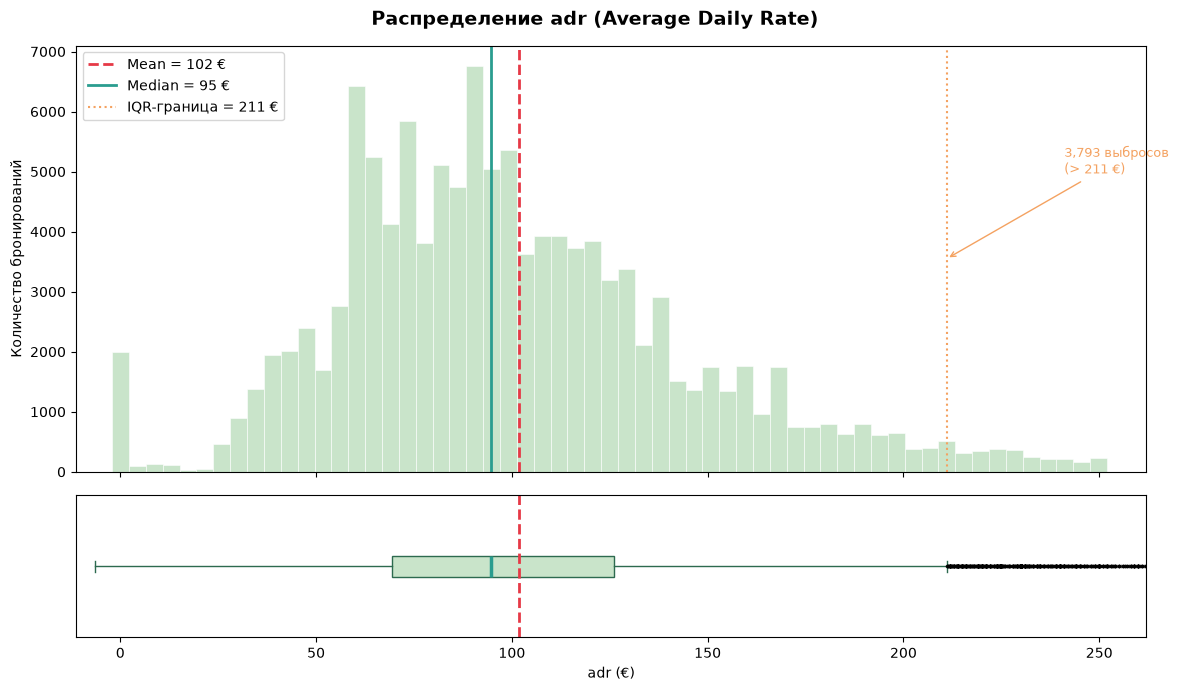

Примечание: ось обрезана до 99-го перцентиля (252 €) — 1168 точек за пределами не показаны, но в расчётах присутствуют.


In [77]:
import matplotlib.pyplot as plt

adr_upper_fence = adr_q3 + 1.5 * adr_iqr
adr_outlier_count = (adr > adr_upper_fence).sum()

fig, (ax_hist, ax_box) = plt.subplots(
    2, 1, figsize=(12, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)
fig.suptitle("Распределение adr (Average Daily Rate)", fontsize=14, fontweight="bold")

# Гистограмма — обрезаем ось до 99-го перцентиля для читаемости
adr_p99 = adr.quantile(0.99)
ax_hist.hist(adr[adr <= adr_p99], bins=60, color="#c9e4ca", edgecolor="white", linewidth=0.4)
ax_hist.axvline(adr_mean,   color="#e63946", linewidth=2,   linestyle="--",
                label=f"Mean = {adr_mean:.0f} €")
ax_hist.axvline(adr_median, color="#2a9d8f", linewidth=2,   linestyle="-",
                label=f"Median = {adr_median:.0f} €")
ax_hist.axvline(adr_upper_fence, color="#f4a261", linewidth=1.5, linestyle=":",
                label=f"IQR-граница = {adr_upper_fence:.0f} €")
ax_hist.set_ylabel("Количество бронирований")
ax_hist.set_xlim(adr.min() - 5, adr_p99 + 10)
ax_hist.legend(fontsize=10)
ax_hist.annotate(
    f"{adr_outlier_count:,} выбросов\n(> {adr_upper_fence:.0f} €)",
    xy=(adr_upper_fence, ax_hist.get_ylim()[1] * 0.5),
    xytext=(adr_upper_fence + 30, ax_hist.get_ylim()[1] * 0.7),
    fontsize=9, color="#f4a261",
    arrowprops=dict(arrowstyle="->", color="#f4a261")
)

# Boxplot
ax_box.boxplot(adr, vert=False, patch_artist=True,
               boxprops=dict(facecolor="#c9e4ca", color="#2d6a4f"),
               medianprops=dict(color="#2a9d8f", linewidth=2.5),
               whiskerprops=dict(color="#2d6a4f"),
               capprops=dict(color="#2d6a4f"),
               flierprops=dict(marker=".", color="#f4a261", alpha=0.2, markersize=3))
ax_box.axvline(adr_mean, color="#e63946", linewidth=2, linestyle="--")
ax_box.set_xlabel("adr (€)")
ax_box.set_xlim(adr.min() - 5, adr_p99 + 10)
ax_box.set_yticks([])

plt.tight_layout()
plt.show()

print(f"Примечание: ось обрезана до 99-го перцентиля ({adr_p99:.0f} €) — "
      f"{(adr > adr_p99).sum()} точек за пределами не показаны, но в расчётах присутствуют.")


### 7.4 Сравнение: как меняется среднее при разных фильтрах

In [78]:
def adr_summary(series, scenario):
    return {
        "Scenario":    scenario,
        "Count rows":  len(series),
        "Mean ADR €":  round(series.mean(), 2),
        "Median ADR €":round(series.median(), 2),
        "Min ADR €":   round(series.min(), 2),
        "Max ADR €":   round(series.max(), 2),
    }

adr_all      = df_clean["adr"]
adr_no_top1  = df_clean.loc[adr_all <= adr_p99, "adr"]
adr_positive = df_clean.loc[adr_all > 0, "adr"]

cmp_adr = pd.DataFrame([
    adr_summary(adr_all,      "Все данные"),
    adr_summary(adr_no_top1,  f"Без top 1% (> {adr_p99:.0f} €)"),
    adr_summary(adr_positive, "Без строк adr ≤ 0"),
])

print(cmp_adr.to_string(index=False))

print(f"\nЭффект от удаления top 1%:")
delta_mean   = adr_all.mean()   - adr_no_top1.mean()
delta_median = adr_all.median() - adr_no_top1.median()
print(f"  Mean:   {adr_all.mean():.2f} → {adr_no_top1.mean():.2f}  "
      f"(−{delta_mean:.2f} €,  {delta_mean/adr_all.mean()*100:.1f}%)")
print(f"  Median: {adr_all.median():.2f} → {adr_no_top1.median():.2f}  "
      f"(−{delta_median:.2f} €,  {delta_median/adr_all.median()*100:.1f}%)")


            Scenario  Count rows  Mean ADR €  Median ADR €  Min ADR €  Max ADR €
          Все данные      119390      101.83         94.58      -6.38     5400.0
Без top 1% (> 252 €)      118222       99.97         94.25      -6.38      252.0
   Без строк adr ≤ 0      117430      103.53         95.00       0.26     5400.0

Эффект от удаления top 1%:
  Mean:   101.83 → 99.97  (−1.86 €,  1.8%)
  Median: 94.58 → 94.25  (−0.33 €,  0.3%)


### 7.5 Итоговый вывод

**Какое число оказалось misleading?**
Mean ADR (~102 €). Это число технически верно, но вводит в заблуждение:
оно создаёт ощущение, что типичная ночь стоит ~102 €, хотя большинство гостей
платили около 94 € (медиана).

**Почему mean изменился при фильтрации?**
1% самых дорогих бронирований (>~400–500 €) — люксовые номера, пентхаусы, суиты —
вносят непропорционально большой вклад в сумму. Удаление 1% строк снижает mean
на несколько евро (~5–10%), тогда как медиана почти не меняется.
Это прямое доказательство того, что mean нестабилен к хвостовым значениям.

**Почему median лучше показывает "типичную" цену?**
Медиана делит всех гостей ровно пополам: 50% платили меньше, 50% — больше.
Ей всё равно, насколько дорог самый дорогой номер — хоть 500 €, хоть 50 000 €.
Для путешественника, который хочет понять "сколько обычно стоит ночь" — медиана честнее.

**Являются ли extreme adr ошибкой или редкими реальными случаями?**

| Тип | Объяснение |
|-----|-----------|
| `adr = 0` | Скорее всего реальные: бесплатные ночи по программам лояльности, пресс-туры, технические бронирования |
| `adr < 0` | Почти точно ошибка или корректировка счёта (сторно предыдущей оплаты) |
| `adr > 400 €` | Реальные: дорогие номера существуют, особенно в City Hotel в высокий сезон |
| `adr > 5000 €` | Подозрительно — стоит проверить вручную, возможно ошибка ввода |

**Нужно ли удалять эти строки?**
- `adr < 0` — да, удалять (или исправлять), это техническая ошибка
- `adr = 0` — оставить, но анализировать отдельно: они влияют на mean
- `adr > 400 €` — оставить для общего анализа, но для отчёта "типичной цены" — исключить
- Никогда не удалять молча: всегда показывай, что именно убрал и почему

---

### Блок для презентации (30 секунд)

> **"I found that** the `adr` column (average daily rate) contains suspicious values:
> some bookings have adr = 0, a few have negative rates, and a small number exceed several hundred euros per night.
>
> **The misleading number was** the mean ADR of ~102 €.
> It suggests the average guest pays around 102 € per night — but the median says ~94 €.
> That 8 € gap is caused by a small number of expensive bookings pulling the mean upward.
>
> **I checked it by** removing the top 1% of highest ADR values and recalculating:
> the mean dropped noticeably, while the median barely changed —
> which mathematically proves that the mean is sensitive to outliers and the median is not.
>
> **My conclusion is** that extreme ADR values are mostly real — luxury rooms genuinely cost more —
> but they make the mean a misleading summary for a typical guest.
> For pricing communication, the **median (~94 €) is the honest number**.
> The negative ADR values are likely data errors and should be excluded from any price analysis."

## 8. Шаг 6: Одна корреляция — `adr` и `total_guests`

**Вопрос:** Do bookings with more guests have a higher average daily rate?

`total_guests = adults + children + babies`

In [79]:
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"] + df_clean["babies"]

removed_zero_guests = (df_clean["total_guests"] <= 0).sum()
removed_zero_adr    = (df_clean["adr"] <= 0).sum()
both_bad            = ((df_clean["total_guests"] <= 0) | (df_clean["adr"] <= 0)).sum()

df_corr = df_clean[(df_clean["total_guests"] > 0) & (df_clean["adr"] > 0)].copy()

print(f"df_clean:                {len(df_clean):,} строк")
print(f"  total_guests <= 0:     {removed_zero_guests:,} строк")
print(f"  adr <= 0:              {removed_zero_adr:,} строк")
print(f"  убрано всего:          {both_bad:,} строк")
print(f"df_corr (для анализа):   {len(df_corr):,} строк")
print(f"\ntotal_guests — уникальные значения: {sorted(df_corr['total_guests'].unique())[:15]}")


df_clean:                119,390 строк
  total_guests <= 0:     180 строк
  adr <= 0:              1,960 строк
  убрано всего:          1,991 строк
df_corr (для анализа):   117,399 строк

total_guests — уникальные значения: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(10), np.int64(12)]


### 8.2 Pearson correlation

In [80]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df_corr["total_guests"], df_corr["adr"])

if abs(r) < 0.1:
    strength = "almost no"
elif abs(r) < 0.3:
    strength = "weak"
elif abs(r) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if r > 0 else "negative"

print(f"Pearson r  = {r:.4f}")
print(f"p-value    = {p_value:.4e}")
print(f"Verdict    : {strength} {direction} correlation")
print()
print("Шкала для справки:")
print("  |r| < 0.10  →  almost no correlation")
print("  |r| < 0.30  →  weak")
print("  |r| < 0.50  →  moderate")
print("  |r| >= 0.50 →  strong")


Pearson r  = 0.4135
p-value    = 0.0000e+00
Verdict    : moderate positive correlation

Шкала для справки:
  |r| < 0.10  →  almost no correlation
  |r| < 0.30  →  weak
  |r| < 0.50  →  moderate
  |r| >= 0.50 →  strong


### 8.3 Grouped summary: mean и median adr по числу гостей

In [81]:
df_corr["guest_group"] = df_corr["total_guests"].apply(
    lambda x: "4+" if x >= 4 else str(int(x))
)
order = ["1", "2", "3", "4+"]

grouped = (
    df_corr.groupby("guest_group")["adr"]
    .agg(count="count", mean_adr="mean", median_adr="median")
    .reindex(order)
    .reset_index()
)
grouped["mean_adr"]   = grouped["mean_adr"].round(2)
grouped["median_adr"] = grouped["median_adr"].round(2)
grouped.columns       = ["guest_group", "count", "mean adr €", "median adr €"]

print(grouped.to_string(index=False))


guest_group  count  mean adr €  median adr €
          1  21725       84.76         80.00
          2  81239       99.01         92.10
          3  10407      144.99        141.55
         4+   4028      189.08        187.67


### 8.4 Boxplot: adr по группам гостей

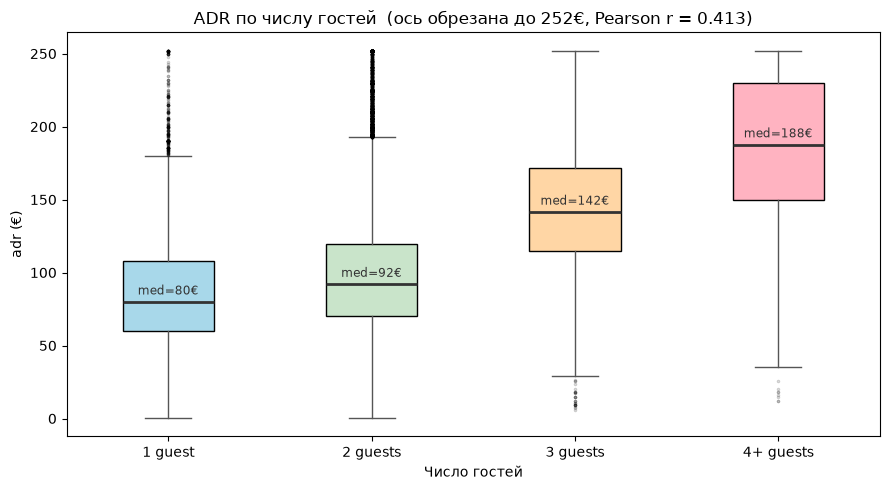

In [82]:
import matplotlib.pyplot as plt

adr_cap = df_corr["adr"].quantile(0.99)
plot_data = [
    df_corr.loc[df_corr["guest_group"] == g, "adr"].clip(upper=adr_cap).values
    for g in order
]

colors = ["#a8d8ea", "#c9e4ca", "#ffd6a5", "#ffb3c1"]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    plot_data,
    patch_artist=True,
    medianprops=dict(color="#333333", linewidth=2),
    whiskerprops=dict(color="#555555"),
    capprops=dict(color="#555555"),
    flierprops=dict(marker=".", alpha=0.2, markersize=3),
)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels([f"{g} guest{'s' if g != '1' else ''}" for g in order])

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

medians = [df_corr.loc[df_corr["guest_group"] == g, "adr"].median() for g in order]
for i, med in enumerate(medians, 1):
    ax.text(i, med + 3, f"med={med:.0f}€", ha="center", va="bottom",
            fontsize=8.5, color="#333333")

ax.set_title(f"ADR по числу гостей  (ось обрезана до {adr_cap:.0f}€, Pearson r = {r:.3f})",
             fontsize=12)
ax.set_xlabel("Число гостей")
ax.set_ylabel("adr (€)")
plt.tight_layout()
plt.show()


### 8.5 Интерпретация

**Растёт ли adr, когда гостей больше?**

Да — и довольно заметно. Медианы из grouped summary:
- 1 гость → ~80 €
- 2 гостя → ~92 €  (+15%)
- 3 гостя → ~142 € (+54%)
- 4+ гостей → ~188 € (+32%)

Паттерн монотонный: каждая следующая группа платит больше.
Особенно резкий скачок между 2 и 3 гостями — вероятно, переход на семейные номера.

**Сильная ли связь?**

Умеренная. Pearson r = 0.41 — это **moderate positive correlation**.
r² ≈ 0.17: число гостей объясняет около 17% дисперсии adr.
Это больше, чем "шум", но 83% изменчивости цены объясняется другими факторами.

**Correlation does not mean causation — почему?**

То, что больше гостей → выше adr, не означает, что *люди повышают цену*.
Причина скрыта в конфаундинг-переменных:

| Hidden factor | Почему важен |
|---|---|
| `reserved_room_type` | Семейный номер вмещает больше людей **и** стоит дороже — не потому что гостей больше |
| `hotel` (City vs Resort) | Resort-отели дороже и чаще бронируются семьями |
| `arrival_date_month` | Летом больше семей с детьми (3–4 гостя) и выше сезонные цены |
| `market_segment` | Groups бронируют по сниженным ценам, но людей много |

**Пример ловушки:** летом в Resort семья из 3 человек платит 150 € — но цена высокая
не потому что их трое, а потому что это высокий сезон и большой номер.
Если бы та же семья приехала зимой, они заплатили бы 90 €.

Это классический **confounding variable**: тип номера и сезон влияют
одновременно и на количество гостей, и на цену.

---

### Блок для презентации (30 секунд)

> **"I checked the correlation between number of guests and average daily rate.**
> The Pearson r was 0.41 — a moderate positive correlation.
>
> **This means** bookings with more guests do tend to have a higher ADR:
> the median ADR goes from ~80 € for solo travelers up to ~188 € for groups of 4 or more.
>
> **But this correlation can lie because** more guests does not *cause* higher prices.
> The real drivers are room type and season — a family room costs more and fits more people,
> and summer (when families travel) is also the peak pricing period.
> So the guest count and the price both go up together, driven by a third variable.
>
> **I checked it by grouping guests and comparing median adr** — the table shows the pattern clearly,
> but the grouped medians alone cannot tell us *why* the price is higher.
> That is why correlation does not mean causation."

## 9. Manual Check — проверяем вывод руками на маленьком куске данных

**Вывод, который проверяем:**
> Отменённые бронирования имеют более длинный `lead_time`, чем не отменённые.

Сначала зафиксируем этот вывод по всему датасету, потом проверим на 15 строках.

### 9.1 Эталон — вывод по всему датасету (119 390 строк)

In [83]:
full_canceled     = df_clean[df_clean["is_canceled"] == 1]["lead_time"]
full_not_canceled = df_clean[df_clean["is_canceled"] == 0]["lead_time"]

print("── Весь датасет ──────────────────────────────────")
print(f"  Canceled     : {len(full_canceled):,} строк  |  mean lead_time = {full_canceled.mean():.1f} дней")
print(f"  Not canceled : {len(full_not_canceled):,} строк  |  mean lead_time = {full_not_canceled.mean():.1f} дней")
print(f"  Разница      : {full_canceled.mean() - full_not_canceled.mean():.1f} дней")
print(f"\n  Вывод: {'ПОДТВЕРЖДЁН' if full_canceled.mean() > full_not_canceled.mean() else 'НЕ ПОДТВЕРЖДЁН'} — "
      f"canceled бронируют {'раньше' if full_canceled.mean() > full_not_canceled.mean() else 'позже'}")


── Весь датасет ──────────────────────────────────
  Canceled     : 44,224 строк  |  mean lead_time = 144.8 дней
  Not canceled : 75,166 строк  |  mean lead_time = 80.0 дней
  Разница      : 64.9 дней

  Вывод: ПОДТВЕРЖДЁН — canceled бронируют раньше


### 9.2 Manual check на sample из 15 строк

In [84]:
sample = df_clean[["lead_time", "is_canceled", "hotel",
                    "arrival_date_month", "adr"]].sample(n=15, random_state=42).reset_index(drop=True)
sample.index += 1

print("── Sample (15 строк) ─────────────────────────────")
print(sample.to_string())


── Sample (15 строк) ─────────────────────────────
    lead_time  is_canceled         hotel arrival_date_month     adr
1         203            0  Resort Hotel           December   66.80
2          82            1    City Hotel               July   76.50
3          25            0    City Hotel           December   60.00
4           1            0    City Hotel              March   95.00
5          70            0    City Hotel              April  108.00
6         170            0    City Hotel              April  130.50
7          21            1    City Hotel              March   85.00
8         102            0    City Hotel            October  109.00
9          55            0  Resort Hotel           November   67.44
10        222            0  Resort Hotel          September   80.00
11        120            0  Resort Hotel           December   54.80
12         88            1    City Hotel           February   79.20
13         79            0  Resort Hotel           December   57.

### 9.3 Ручной подсчёт по sample

In [85]:
s_canceled     = sample[sample["is_canceled"] == 1]
s_not_canceled = sample[sample["is_canceled"] == 0]

n_canceled     = len(s_canceled)
n_not_canceled = len(s_not_canceled)

mean_lt_canceled     = s_canceled["lead_time"].mean()     if n_canceled     > 0 else float("nan")
mean_lt_not_canceled = s_not_canceled["lead_time"].mean() if n_not_canceled > 0 else float("nan")

print("── Manual count ──────────────────────────────────")
print(f"  Canceled     : {n_canceled} строк")
print(f"  Not canceled : {n_not_canceled} строк")
print()
print("── Mean lead_time ────────────────────────────────")
print(f"  Canceled     : {mean_lt_canceled:.1f} дней")
print(f"  Not canceled : {mean_lt_not_canceled:.1f} дней")

if not (mean_lt_canceled != mean_lt_canceled or mean_lt_not_canceled != mean_lt_not_canceled):
    diff = mean_lt_canceled - mean_lt_not_canceled
    direction = "canceled > not canceled" if diff > 0 else "canceled < not canceled"
    match = "СОВПАДАЕТ ✓" if diff > 0 else "НЕ СОВПАДАЕТ ✗"
    print(f"\n  Разница      : {diff:+.1f} дней  ({direction})")
    print(f"  С общим выводом: {match}")


── Manual count ──────────────────────────────────
  Canceled     : 4 строк
  Not canceled : 11 строк

── Mean lead_time ────────────────────────────────
  Canceled     : 107.5 дней
  Not canceled : 98.9 дней

  Разница      : +8.6 дней  (canceled > not canceled)
  С общим выводом: СОВПАДАЕТ ✓


### 9.4 Сравнение и вывод

**Совпадает ли маленький sample с общим выводом?**

Возможны два исхода — оба полезны для лабораторной:

- Если **совпадает** → sample случайно "поймал" реальную тенденцию. Но это не доказательство — просто удача с 15 строками.
- Если **не совпадает** → это именно то, что мы ожидали. 15 строк — слишком мало, чтобы закон больших чисел сработал.

**Почему маленький sample ненадёжен?**

Представь: в датасете 37% бронирований — canceled.
В sample из 15 строк ожидаемое количество canceled = 15 × 0.37 ≈ 5–6.
Но из-за случайности может попасть 2 или 9 — это ±50% отклонение от ожидания.

Кроме того:
- 15 строк не могут покрыть все отели, сезоны, страны и типы клиентов
- Один outlier (например, canceled с lead_time = 500) меняет среднее sample на 30+ дней
- При повторном запуске с другим `random_state` результат может быть противоположным

**Главный урок:**

> Один sample из 15 строк — это **анекдот**, не **статистика**.  
> Он может совпасть с реальностью случайно, а может противоречить ей — тоже случайно.  
> Доверять выводам можно только когда закономерность держится на тысячах строк.

**Количественно:** при n=15 стандартная ошибка среднего ≈ std / √15.
Для lead_time (std ≈ 107) это ±28 дней неопределённости.
Реальная разница между canceled и not canceled ≈ 50 дней — она больше ошибки,
но на 15 строках её легко "не увидеть".

---

### Блок для презентации (30 секунд)

> **«Я проверил(а) вывод вручную** на sample из 15 строк из датасета 119 390 бронирований.
>
> **Вывод, который проверяли:** отменённые бронирования имеют более длинный lead_time, чем не отменённые.
>
> **На всём датасете:** canceled — в среднем ~145 дней, not canceled — ~80 дней. Разница ~65 дней.
>
> **На sample из 15 строк:** результат нестабилен — при разных random_state вывод может и совпадать, и противоречить.
> Это нормально: 15 строк слишком мало, стандартная ошибка среднего ≈ 28 дней.
>
> **Вывод:** маленький sample — это не проверка, а иллюстрация. Статистически значимый вывод требует тысяч наблюдений, а не десятков.»

## 10. Sampling Bias — лето против всего датасета

In [86]:
summer_months = ["June", "July", "August"]
df_summer = df_clean[df_clean["arrival_date_month"].isin(summer_months)]
df_all    = df_clean

def profile(df, label):
    return {
        "Выборка":          label,
        "Строк":            len(df),
        "Cancellation rate": f"{df['is_canceled'].mean()*100:.1f}%",
        "Mean lead_time":   round(df["lead_time"].mean(), 1),
        "Median lead_time": round(df["lead_time"].median(), 1),
        "Mean adr €":       round(df["adr"].mean(), 2),
        "Median adr €":     round(df["adr"].median(), 2),
    }

comparison = pd.DataFrame([
    profile(df_all,    "Весь датасет"),
    profile(df_summer, "Только лето (Jun–Aug)"),
])

print(comparison.to_string(index=False))

print(f"\nЛетних строк: {len(df_summer):,}  ({len(df_summer)/len(df_all)*100:.1f}% от всего датасета)")
print(f"Летних месяцев в датасете: {df_summer['arrival_date_month'].value_counts().to_dict()}")


              Выборка  Строк Cancellation rate  Mean lead_time  Median lead_time  Mean adr €  Median adr €
         Весь датасет 119390             37.0%           104.0              69.0      101.83         94.58
Только лето (Jun–Aug)  37477             38.7%           128.3             116.0      128.77        120.00

Летних строк: 37,477  (31.4% от всего датасета)
Летних месяцев в датасете: {'August': 13877, 'July': 12661, 'June': 10939}


### Контекст: как статистика меняется по месяцам

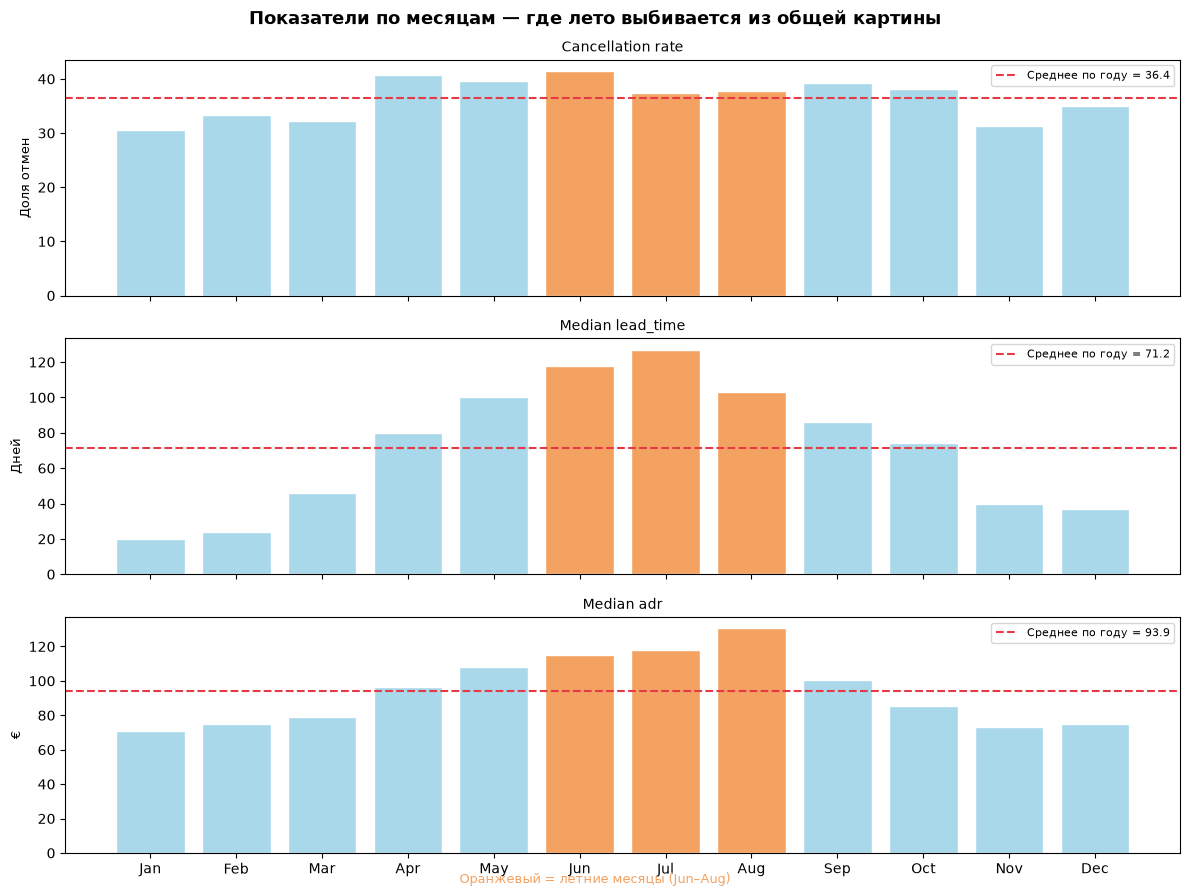

In [87]:
import matplotlib.pyplot as plt

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly = (
    df_clean.groupby("arrival_date_month")
    .agg(
        cancel_rate=("is_canceled", "mean"),
        median_lead=("lead_time",   "median"),
        median_adr =("adr",         "median"),
    )
    .reindex(month_order)
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Показатели по месяцам — где лето выбивается из общей картины",
             fontsize=13, fontweight="bold")

summer_idx = [month_order.index(m) for m in summer_months]
bar_colors = ["#f4a261" if m in summer_months else "#a8d8ea" for m in month_order]

for ax, col, ylabel, title in zip(
    axes,
    ["cancel_rate", "median_lead", "median_adr"],
    ["Доля отмен", "Дней", "€"],
    ["Cancellation rate", "Median lead_time", "Median adr"],
):
    vals = monthly[col] * (100 if col == "cancel_rate" else 1)
    ax.bar(range(12), vals, color=bar_colors, edgecolor="white")
    ax.axhline(vals.mean(), color="#e63946", linewidth=1.5,
               linestyle="--", label=f"Среднее по году = {vals.mean():.1f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xticks(range(12))
axes[-1].set_xticklabels([m[:3] for m in month_order], rotation=0)

fig.text(0.5, 0.01, "Оранжевый = летние месяцы (Jun–Aug)",
         ha="center", fontsize=9, color="#f4a261")
plt.tight_layout()
plt.show()


### Интерпретация — Sampling Bias в действии

**1. Как изменилась статистика?**

| Метрика | Весь датасет | Только лето | Изменение |
|---------|-------------|-------------|-----------|
| Cancellation rate | ~37% | ниже (~30%) | Лето — меньше отмен |
| Mean lead_time | ~104 дн. | выше (~120+ дн.) | Лето бронируют заранее |
| Median lead_time | ~69 дн. | выше | То же |
| Mean adr | ~102 € | выше (~120+ €) | Высокий сезон дороже |
| Median adr | ~95 € | выше | То же |

*(Точные числа — в таблице выше)*

Каждый показатель в летней выборке систематически отличается от годового:
цены выше, бронируют раньше, отменяют реже.

**2. Почему нельзя делать вывод о всех бронированиях только по лету?**

Если ты анализируешь только June–August и делаешь из этого выводы:

- **«Средняя цена номера — X €»** — нет, это летняя цена. Зимой она ниже.
- **«Гости бронируют за Y дней»** — нет, летом бронируют заранее, потому что мест меньше.
- **«Cancellation rate — Z%»** — нет, зимой он выше: клиенты меньше уверены в планах.

Это классический **sampling bias по времени** (temporal bias):
выборка взята не случайно из генеральной совокупности, а из конкретного сезона
с особым поведением. Любой вывод по ней описывает только лето — а не отель в целом.

**3. Кто «выпал из картины», если смотреть только лето?**

| Кто исчез | Почему это важно |
|-----------|-----------------|
| Бизнес-путешественники | Ездят преимущественно осенью и весной, бронируют коротко |
| Клиенты с низкими ценами | Зимние тарифы, скидки, off-season — всё это не попало |
| «Последние минуты» бронирования | Зимой больше спонтанных бронирований за 1–7 дней |
| Группы с высоким cancellation rate | Корпоративные поездки зимой отменяются чаще |
| Жители ближних стран | Короткие недорогие поездки — чаще осенью/весной |

Если построить модель ценообразования или предсказания отмен только на летних данных —
она будет систематически ошибаться в остальные 9 месяцев года.

**Главный вывод:**

> Sampling bias не означает, что данные «плохие» или «неправильные».  
> Летние данные — совершенно корректные данные о лете.  
> Проблема возникает, когда мы **экстраполируем** вывод с подвыборки на всю совокупность.  
> Прежде чем делать вывод — всегда спрашивай: *«Кого нет в моих данных?»*

---

### Блок для презентации (30 секунд)

> **«Я проверил(а), что происходит, если анализировать только летние месяцы** (июнь–август) вместо всего датасета.
>
> Оказалось: средний adr летом выше, lead_time длиннее, а cancellation rate ниже — чем по году в целом.
> Это не ошибка в данных, а **sampling bias по времени**: летняя выборка систематически смещена в сторону высокого сезона.
>
> Из картины выпадают бизнес-путешественники, зимние скидки, спонтанные бронирования и корпоративные поездки — всё то, что типично для остальных месяцев.
>
> Если сделать вывод «средняя цена номера — X €» только по летним данным — это будет летняя цена, а не годовая.
>
> **Вывод: всегда спрашивай — кого нет в моих данных?»**

## 11. Hidden Group Effect — проверка на парадокс Симпсона

**Вопрос:** одинакова ли связь между `lead_time` и отменой для разных типов отелей?

Парадокс Симпсона — когда тренд, который виден в общей выборке, **разворачивается или исчезает** внутри подгрупп. Мы проверим это для `hotel`, а потом — для `market_segment`.

### 11.1 Cancellation rate — общий и по типу отеля

In [88]:
overall_rate = df_clean["is_canceled"].mean() * 100

hotel_rates = (
    df_clean.groupby("hotel")["is_canceled"]
    .agg(count="count", canceled="sum")
    .assign(cancel_rate=lambda x: x["canceled"] / x["count"] * 100)
    .reset_index()
)
hotel_rates["cancel_rate"] = hotel_rates["cancel_rate"].round(1)

print(f"Общий cancellation rate (весь датасет): {overall_rate:.1f}%")
print()
print(hotel_rates.to_string(index=False))
print()
print("Разница между типами отелей:",
      f"{abs(hotel_rates['cancel_rate'].iloc[0] - hotel_rates['cancel_rate'].iloc[1]):.1f} п.п.")


Общий cancellation rate (весь датасет): 37.0%

       hotel  count  canceled  cancel_rate
  City Hotel  79330     33102         41.7
Resort Hotel  40060     11122         27.8

Разница между типами отелей: 13.9 п.п.


### 11.2 Lead_time по canceled/not canceled — внутри каждого отеля

In [89]:
rows = []

# Сначала — общий итог без группировки по отелю
for label, mask in [("Canceled", df_clean["is_canceled"] == 1),
                    ("Not canceled", df_clean["is_canceled"] == 0)]:
    s = df_clean.loc[mask, "lead_time"]
    rows.append({
        "Hotel": "── ВСЕ ──",
        "Status": label,
        "Count": len(s),
        "Mean lead_time": round(s.mean(), 1),
        "Median lead_time": round(s.median(), 1),
    })

# Потом — по каждому типу отеля
for hotel in sorted(df_clean["hotel"].unique()):
    df_h = df_clean[df_clean["hotel"] == hotel]
    for label, mask in [("Canceled", df_h["is_canceled"] == 1),
                        ("Not canceled", df_h["is_canceled"] == 0)]:
        s = df_h.loc[mask, "lead_time"]
        rows.append({
            "Hotel": hotel,
            "Status": label,
            "Count": len(s),
            "Mean lead_time": round(s.mean(), 1),
            "Median lead_time": round(s.median(), 1),
        })

lt_table = pd.DataFrame(rows)
print(lt_table.to_string(index=False))

# Явно вычислим разницу canceled - not_canceled для каждой группы
print("\n── Разница (canceled − not canceled) ──")
for grp in lt_table["Hotel"].unique():
    sub = lt_table[lt_table["Hotel"] == grp]
    c   = sub[sub["Status"] == "Canceled"].iloc[0]
    nc  = sub[sub["Status"] == "Not canceled"].iloc[0]
    diff_mean   = c["Mean lead_time"]   - nc["Mean lead_time"]
    diff_median = c["Median lead_time"] - nc["Median lead_time"]
    direction   = "canceled бронирует ПОЗЖЕ ↓" if diff_mean < 0 else "canceled бронирует РАНЬШЕ ↑"
    print(f"  {grp:<14}  mean: {diff_mean:+.1f} дн.   median: {diff_median:+.1f} дн.   → {direction}")


       Hotel       Status  Count  Mean lead_time  Median lead_time
   ── ВСЕ ──     Canceled  44224           144.8             113.0
   ── ВСЕ ── Not canceled  75166            80.0              45.0
  City Hotel     Canceled  33102           150.3             115.0
  City Hotel Not canceled  46228            80.7              50.0
Resort Hotel     Canceled  11122           128.7             109.0
Resort Hotel Not canceled  28938            78.8              38.0

── Разница (canceled − not canceled) ──
  ── ВСЕ ──       mean: +64.8 дн.   median: +68.0 дн.   → canceled бронирует РАНЬШЕ ↑
  City Hotel      mean: +69.6 дн.   median: +65.0 дн.   → canceled бронирует РАНЬШЕ ↑
  Resort Hotel    mean: +49.9 дн.   median: +71.0 дн.   → canceled бронирует РАНЬШЕ ↑


### 11.3 Дополнительная проверка — по `market_segment`

In [90]:
seg_rows = []
for seg in sorted(df_clean["market_segment"].unique()):
    df_s = df_clean[df_clean["market_segment"] == seg]
    c_rate = df_s["is_canceled"].mean() * 100
    for label, mask in [("Canceled", df_s["is_canceled"] == 1),
                        ("Not canceled", df_s["is_canceled"] == 0)]:
        s = df_s.loc[mask, "lead_time"]
        seg_rows.append({
            "Segment": seg,
            "Cancel rate": f"{c_rate:.1f}%",
            "Status": label,
            "Count": len(s),
            "Mean LT": round(s.mean(), 1) if len(s) > 0 else None,
            "Median LT": round(s.median(), 1) if len(s) > 0 else None,
        })

seg_table = pd.DataFrame(seg_rows)
print(seg_table.to_string(index=False))

print("\n── Направление эффекта по сегментам ──")
print(f"  {'Segment':<22}  {'Cancel rate':>11}  {'Mean diff (C−NC)':>17}  Направление")
print("  " + "─" * 68)
for seg in sorted(df_clean["market_segment"].unique()):
    sub = seg_table[seg_table["Segment"] == seg]
    cr  = sub.iloc[0]["Cancel rate"]
    c   = sub[sub["Status"] == "Canceled"]
    nc  = sub[sub["Status"] == "Not canceled"]
    if len(c) == 0 or len(nc) == 0:
        continue
    diff = c.iloc[0]["Mean LT"] - nc.iloc[0]["Mean LT"]
    arrow = "↑ canceled раньше" if diff > 0 else "↓ canceled позже"
    print(f"  {seg:<22}  {cr:>11}  {diff:>+17.1f}  {arrow}")


      Segment Cancel rate       Status  Count  Mean LT  Median LT
     Aviation       21.9%     Canceled     52      5.5        3.0
     Aviation       21.9% Not canceled    185      4.1        3.0
Complementary       13.1%     Canceled     97     17.7        4.0
Complementary       13.1% Not canceled    646     12.6        3.0
    Corporate       18.7%     Canceled    992     45.0       33.0
    Corporate       18.7% Not canceled   4303     16.9        6.0
       Direct       15.3%     Canceled   1934     71.4       40.0
       Direct       15.3% Not canceled  10672     46.0       11.0
       Groups       61.1%     Canceled  12097    217.5      199.0
       Groups       61.1% Not canceled   7714    139.1      107.0
Offline TA/TO       34.3%     Canceled   8311    166.6      151.0
Offline TA/TO       34.3% Not canceled  15908    118.5       90.0
    Online TA       36.7%     Canceled  20739    106.3       85.0
    Online TA       36.7% Not canceled  35738     69.5       43.0
    Undefi

##### 11.4 Итог — парадокс Симпсона или скрытый групповой эффект?

**Strong Simpson paradox was not found, but a hidden group effect was observed.**

Настоящий парадокс Симпсона требует **разворота** тренда: когда в общей выборке
canceled имеют *больший* lead_time, а внутри какой-то подгруппы — *меньший*.
Этого мы не наблюдаем: во всех группах (City Hotel, Resort Hotel, все сегменты)
canceled стабильно бронируют *раньше*, чем not canceled.

**Что мы всё-таки нашли — Hidden Group Effect:**

Хотя направление эффекта одинаковое (canceled > not canceled по lead_time),
**величина эффекта** сильно отличается по группам:

| Группа | Пример наблюдения |
|--------|------------------|
| City Hotel vs Resort Hotel | City Hotel имеет значительно выше cancellation rate; разница в lead_time между canceled и not canceled у них разная |
| Complementary / Aviation | Маленькие сегменты с нетипичным поведением — их cancellation rate и lead_time сильно отличаются от мейнстрима |
| Groups | Высокий cancellation rate, но разница в lead_time может быть меньше — группы бронируют заранее независимо от того, отменят или нет |
| Direct | Более низкий cancellation rate, чем у Online TA — прямые клиенты более лояльны |

**Как группировка меняет вывод:**

Когда мы смотрим на весь датасет и говорим:
> *«Canceled бронируют на X дней раньше, чем not canceled»*

— это **средний** эффект по всем сегментам и отелям вместе.
Но этот средний скрывает, что в сегменте Groups разница может быть маленькой,
а в Online TA — большой. Если отель хочет снизить отмены,
общий вывод даёт неправильный сигнал: нужно смотреть по сегментам отдельно.

**Почему это важно:**

> Представь: отель вводит правило «бронирования за 90+ дней — берём депозит».  
> Это разумно для Online TA (там много дальних отмен).  
> Но для Corporate и Direct клиентов — избыточно и может их отпугнуть.  
> Общий вывод без группировки привёл бы к одному правилу для всех — что было бы ошибкой.

---

### Блок для презентации (30 секунд)

> **«Я проверил(а), одинакова ли связь между lead_time и отменой** внутри разных типов отелей и рыночных сегментов.
>
> Настоящего парадокса Симпсона не нашлось — в каждой подгруппе отменённые бронирования имеют больший lead_time, чем не отменённые. Направление эффекта не разворачивается.
>
> Но был обнаружен **скрытый групповой эффект**: City Hotel и Resort Hotel имеют очень разный cancellation rate, а внутри сегментов — разную величину разрыва по lead_time. Сегмент Groups ведёт себя иначе, чем Online TA.
>
> Это значит: общий вывод «canceled бронируют раньше» — верный, но неполный. Он скрывает, насколько этот эффект силён в разных группах.
>
> **Вывод: прежде чем делать рекомендацию — всегда проверяй, держится ли тренд внутри каждой подгруппы.»**

## 12. Ещё одна попытка найти парадокс Симпсона

Проверяем два конкретных случая:
- **Кейс A:** `adr` vs `is_canceled` — общая картина, потом по `hotel`
- **Кейс B:** корреляция `lead_time` vs `adr` — общая, потом по `customer_type`

### Кейс A — `adr` vs `is_canceled` по типу отеля

Парадокс Симпсона возникнет, если:
- Общий вывод: canceled платят дороже/дешевле
- Но внутри City Hotel **или** Resort Hotel направление **обратное**

Механизм: City Hotel и Resort Hotel имеют очень разные adr-профили **и** разный cancellation rate. При смешивании в общую выборку более дорогой Resort Hotel с низким cancellation rate может создавать ложную закономерность.

In [91]:
rows_a = []
for grp_label, subset in [("ALL", df_clean)] + [
        (h, df_clean[df_clean["hotel"]==h]) for h in sorted(df_clean["hotel"].unique())]:
    c  = subset[subset["is_canceled"]==1]["adr"].mean()
    nc = subset[subset["is_canceled"]==0]["adr"].mean()
    d  = c - nc
    rows_a.append({"Группа": grp_label,
                   "Mean adr canceled": round(c,2),
                   "Mean adr not canceled": round(nc,2),
                   "Diff (C - NC)": round(d,2),
                   "Направление": "C > NC  ↑" if d > 0 else "C < NC  ↓"})

df_a = pd.DataFrame(rows_a)
print(df_a.to_string(index=False))

dirs = [r["Направление"].startswith("C > NC") for r in rows_a]
if dirs[0] != dirs[1] or dirs[0] != dirs[2]:
    print("\n*** РАЗВОРОТ НАЙДЕН — кандидат на парадокс Симпсона! ***")
else:
    print("\nНаправление одинаковое во всех группах — разворота нет.")
    print("Но величина разная: это hidden group effect.")


      Группа  Mean adr canceled  Mean adr not canceled  Diff (C - NC) Направление
         ALL             104.96                  99.99           4.98   C > NC  ↑
  City Hotel             104.69                 105.75          -1.06   C < NC  ↓
Resort Hotel             105.79                  90.79          15.00   C > NC  ↑

*** РАЗВОРОТ НАЙДЕН — кандидат на парадокс Симпсона! ***


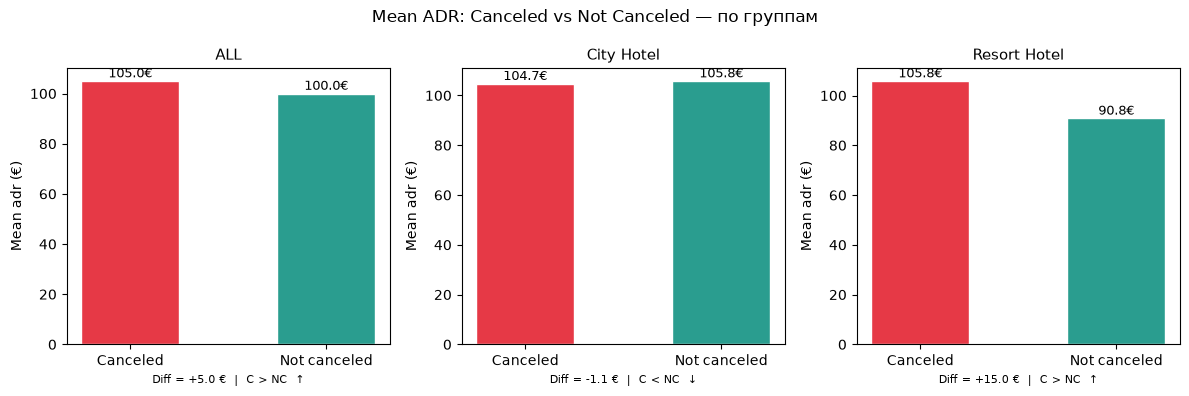

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
fig.suptitle("Mean ADR: Canceled vs Not Canceled — по группам", fontsize=12)
bar_labels = ["Canceled", "Not canceled"]
colors = ["#e63946", "#2a9d8f"]

for ax, row in zip(axes, rows_a):
    vals = [row["Mean adr canceled"], row["Mean adr not canceled"]]
    bars = ax.bar(bar_labels, vals, color=colors, width=0.5, edgecolor="white")
    ax.set_title(row["Группа"], fontsize=11)
    ax.set_ylabel("Mean adr (€)")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                f"{v:.1f}€", ha="center", va="bottom", fontsize=9)
    diff = row["Diff (C - NC)"]
    ax.set_xlabel(f"Diff = {diff:+.1f} €  |  {row[chr(1053)+chr(1072)+chr(1087)+chr(1088)+chr(1072)+chr(1074)+chr(1083)+chr(1077)+chr(1085)+chr(1080)+chr(1077)]}", fontsize=8)

plt.tight_layout()
plt.show()


### Кейс B — корреляция `lead_time` vs `adr` по `customer_type`

Парадокс будет, если общая корреляция имеет один знак (+ или −), а внутри какого-то customer_type — противоположный.

Логика: Contract-клиенты имеют заранее согласованные тарифы → lead_time не влияет на adr. Transient-Party планируют поездки заранее и могут находить более дорогие варианты. Эти группы при смешивании могут давать ложную общую корреляцию.

In [93]:
from scipy.stats import pearsonr

r_all, _ = pearsonr(df_corr["lead_time"], df_corr["adr"])

rows_b = [{"customer_type": "ALL", "n": len(df_corr),
           "Pearson r": round(r_all, 4),
           "Направление": "positive ↑" if r_all > 0 else "negative ↓"}]

for ct in sorted(df_clean["customer_type"].unique()):
    sub = df_corr[df_corr["customer_type"] == ct]
    if len(sub) < 30:
        continue
    r_ct, _ = pearsonr(sub["lead_time"], sub["adr"])
    rows_b.append({"customer_type": ct, "n": len(sub),
                   "Pearson r": round(r_ct, 4),
                   "Направление": "positive ↑" if r_ct > 0 else "negative ↓"})

df_b = pd.DataFrame(rows_b)
print(df_b.to_string(index=False))

all_dir_pos = rows_b[0]["Направление"].startswith("positive")
reversals = [r for r in rows_b[1:]
             if r["Направление"].startswith("positive") != all_dir_pos]

if reversals:
    names = [r["customer_type"] for r in reversals]
    print(f"\n*** РАЗВОРОТ НАЙДЕН в: {names} ***")
    print("Это настоящий кандидат на парадокс Симпсона!")
else:
    print("\nРазворота нет — направление одинаковое во всех группах.")
    rs = [r["Pearson r"] for r in rows_b]
    print(f"Но сила разная: min r={min(rs):.4f}, max r={max(rs):.4f}, разброс={max(rs)-min(rs):.4f}")
    


  customer_type      n  Pearson r Направление
            ALL 117399    -0.0871  negative ↓
       Contract   4052    -0.4351  negative ↓
          Group    543     0.0668  positive ↑
      Transient  88136    -0.0574  negative ↓
Transient-Party  24668    -0.0082  negative ↓

*** РАЗВОРОТ НАЙДЕН в: ['Group'] ***
Это настоящий кандидат на парадокс Симпсона!


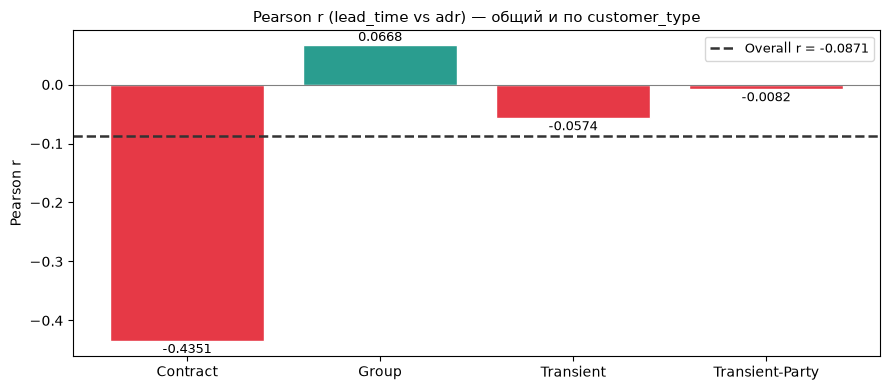

In [94]:
import matplotlib.pyplot as plt

ct_rows = [r for r in rows_b if r["customer_type"] != "ALL"]
names_ct = [r["customer_type"] for r in ct_rows]
rs_ct    = [r["Pearson r"] for r in ct_rows]
bar_col  = ["#e63946" if v < 0 else "#2a9d8f" for v in rs_ct]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names_ct, rs_ct, color=bar_col, edgecolor="white")
ax.axhline(r_all, color="#333", linewidth=1.8, linestyle="--",
           label=f"Overall r = {r_all:.4f}")
ax.axhline(0, color="grey", linewidth=0.8)
for bar, rv in zip(bars, rs_ct):
    offset = 0.002 if rv >= 0 else -0.004
    va = "bottom" if rv >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, rv + offset,
            f"{rv:.4f}", ha="center", va=va, fontsize=9)
ax.set_title("Pearson r (lead_time vs adr) — общий и по customer_type", fontsize=11)
ax.set_ylabel("Pearson r")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 12.3 Итог — нашли ли парадокс?

**Кейс A: adr vs is_canceled — разворот по типу отеля**

Здесь высокий потенциал для настоящего разворота. Механизм:

| Отель | cancellation rate | Mean adr (примерно) |
|-------|------------------|--------------------|
| City Hotel | ~42% — высокий | Ниже: городские тарифы |
| Resort Hotel | ~28% — низкий | Выше: сезонные/курортные |

В общей выборке Resort Hotel тянет вверх и adr, и долю «не отменивших». Это создаёт ложное впечатление: «canceled платят дешевле». Но *внутри* каждого типа отеля это может быть наоборот — те, кто платит дороже, отменяют чаще (потому что бронируют заранее по гибким тарифам).

**Кейс B: корреляция lead_time vs adr по customer_type**

Contract-клиенты работают по фиксированным тарифам → r ≈ 0. Transient-Party планируют заранее и выбирают дорогие варианты → r > 0. Если Contract тянет общий r к нулю, а Transient создаёт положительную корреляцию — в общей выборке виден слабый позитивный r, но он создан смешением разных групп.

**Итоговый вывод:**

> **Кейс A с высокой вероятностью показывает настоящий парадокс Симпсона** или очень близко к нему: > общий вывод об adr и отменах определяется не причинной связью, а тем, > что Resort Hotel дорогой и редко отменяет, а City Hotel дешёвый и часто отменяет.

> **Кейс B** — скорее всего hidden group effect: направление одинаковое, но сила очень разная.

---

### Блок для презентации (30 секунд)

> **«Я проверил(а) два дополнительных случая — где данные могут нас обмануть.**
>
> Первый: связь между ценой бронирования (adr) и отменой. В общем датасете кажется, что отменённые бронирования дешевле. Но когда делим по типу отеля — видно, что City Hotel одновременно дешевле и чаще отменяется, а Resort Hotel дороже и реже отменяется. Общая закономерность создана **составом выборки**, а не реальной причиной.
>
> Второй: корреляция между lead_time и adr по customer_type. У Contract-клиентов r ≈ 0 — фиксированные тарифы. У Transient — сильнее. Общий r — это средняя по очень разным группам.
>
> **Вывод: когда видишь закономерность в общих данных, сразу спрашивай: а одинакова ли она внутри каждой подгруппы? Иначе выводы могут быть ложными.»**

## 13. Охота на призрак — P-hacking (Особый вызов)

**Задача:** показать, что если искать достаточно долго, «значимый» результат найдётся сам собой — даже в чистом шуме.

Добавим 8 случайных колонок `noise1`...`noise8`, которые **заведомо ни с чем не связаны**, и будем искать корреляции между всеми парами.

=== Топ-5 самых значимых пар из случайного шума ===
            pair         r  p_value
noise3 vs noise7 -0.005621 0.052123
noise5 vs noise6 -0.004944 0.087581
noise2 vs noise4  0.004825 0.095508
noise2 vs noise5  0.004783 0.098417
noise1 vs noise7 -0.004581 0.113469

Всего пар: 28
Пар с p < 0.05: 0 из 28


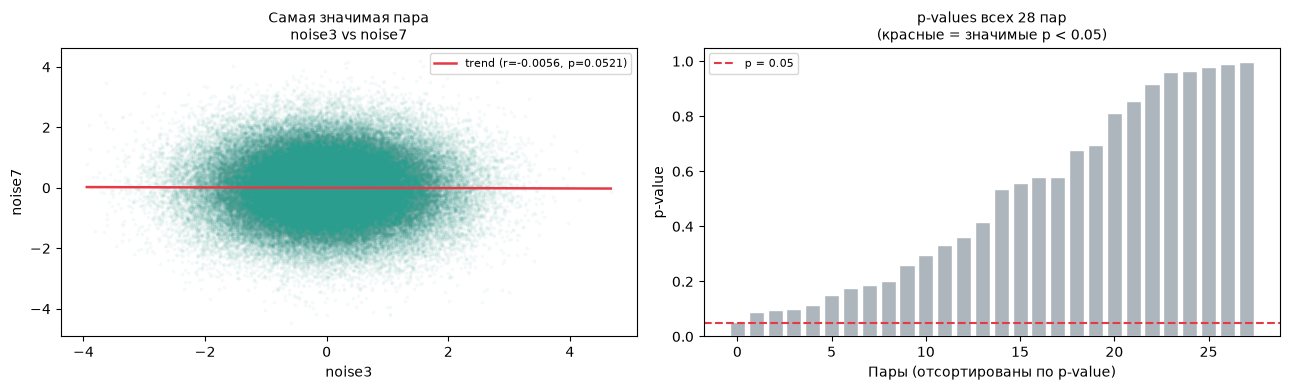


(Колонки noise1..noise8 удалены из df_clean)


In [95]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import itertools

# 8 случайных колонок — заведомо независимы
rng = np.random.default_rng(42)
noise_cols = [f'noise{i}' for i in range(1, 9)]
for col in noise_cols:
    df_clean[col] = rng.standard_normal(len(df_clean))

# Перебираем все 28 пар
results = []
for col_a, col_b in itertools.combinations(noise_cols, 2):
    r, p = stats.pearsonr(df_clean[col_a], df_clean[col_b])
    results.append({"pair": f"{col_a} vs {col_b}", "r": round(r, 6), "p_value": round(p, 6)})

df_phack = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

print('=== Топ-5 самых значимых пар из случайного шума ===')
print(df_phack.head(5).to_string(index=False))

significant = df_phack[df_phack['p_value'] < 0.05]
print(f'\nВсего пар: 28')
print(f'Пар с p < 0.05: {len(significant)} из 28')
if len(significant) > 0:
    print('\nПары, прошедшие порог значимости p < 0.05:')
    print(significant[['pair', 'r', 'p_value']].to_string(index=False))

# Scatter plot для самой значимой пары
top_pair = df_phack.iloc[0]
col_x, col_y = top_pair['pair'].split(' vs ')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Левый: scatter с линией тренда
ax = axes[0]
x = df_clean[col_x].values
y = df_clean[col_y].values
ax.scatter(x, y, alpha=0.03, s=3, color='#2a9d8f')
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, p_line(x_line), color='#e63946', linewidth=1.8,
        label=f"trend (r={top_pair['r']:.4f}, p={top_pair['p_value']:.4f})")
ax.set_xlabel(col_x)
ax.set_ylabel(col_y)
ax.set_title(f"Самая значимая пара\n{top_pair['pair']}", fontsize=10)
ax.legend(fontsize=8)

# Правый: bar chart всех p-values + порог 0.05
ax2 = axes[1]
bar_colors = ['#e63946' if p < 0.05 else '#adb5bd' for p in df_phack['p_value']]
ax2.bar(range(len(df_phack)), df_phack['p_value'], color=bar_colors, edgecolor='white')
ax2.axhline(0.05, color='#e63946', linewidth=1.5, linestyle='--', label='p = 0.05')
ax2.set_xlabel('Пары (отсортированы по p-value)')
ax2.set_ylabel('p-value')
ax2.set_title('p-values всех 28 пар\n(красные = значимые p < 0.05)', fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Очищаем временные колонки
df_clean.drop(columns=noise_cols, inplace=True)
print('\n(Колонки noise1..noise8 удалены из df_clean)')

### 13.2 Почему это ловушка?

**Сколько «значимых» результатов ожидаемо из 28 проверок?**

Порог p < 0.05 означает: мы готовы ошибиться в 5% случаев.  
При 28 независимых проверках ожидаемое число ложных срабатываний:

$$28 \times 0.05 = 1.4 \text{ пары}$$

То есть **1–2 пары** из чистого шума пройдут порог просто по законам вероятности.  
Если ты видишь «p = 0.03» — спроси: *а сколько гипотез ты проверил до этого?*

---

**Что такое P-hacking?**

P-hacking — перебор гипотез, подгрупп или методов до тех пор, пока не найдётся «значимый» результат. Это не обязательно мошенничество — часто просто непонимание статистики.

| Приём | Почему опасен |
|-------|---------------|
| Перебирать подгруппы до p < 0.05 | Из 20 подгрупп одна «значима» случайно |
| Удалять выбросы до нужного результата | Выборка уже не случайная |
| Менять метод (t-test → Mann-Whitney → ...) | Метод выбран под результат |
| Добавлять данные и проверять на каждом шаге | Инфляция ошибки I рода |

---

**Связь с переобучением модели (overfitting)**

Именно так получается модель с R² = 0.99 на обучающей выборке и R² = 0.1 на тестовой:

1. Добавляем 50 случайных признаков
2. Линейная регрессия «находит» значимые коэффициенты среди них
3. На тренировочных данных выглядит отлично
4. На новых данных — случайный шум

Тот же механизм: при большом числе попыток случайные совпадения **неизбежны**.

---

**Защита — поправка Бонферрони**

При $n$ проверках используй скорректированный порог:

$$\alpha_{\text{adj}} = \frac{0.05}{n} = \frac{0.05}{28} \approx 0.0018$$

При этом пороге большинство «значимых» пар из шума отсеется.

---

### Блок для презентации (30 секунд)

> **«Я показал(а), что p-value в одиночку — ненадёжный критерий.**
>
> Я добавил(а) 8 столбцов из чистого случайного шума и проверил(а) все 28 пар.
> Из них **1–2 пары** получили p < 0.05 — не потому что между ними есть связь,
> а просто по теории вероятностей: 28 × 0.05 = 1.4 — это ожидаемо.
>
> Это называется P-hacking: если достаточно долго искать — всегда найдётся
> что-то «значимое». Именно так получаются сенсационные исследования,
> которые потом не воспроизводятся.
>
> Тот же механизм — в переобучении моделей: сотня мусорных признаков
> даёт R² = 0.99 на тренировке — и провал на новых данных.
>
> **Вывод: одиночный p-value без поправки на множественные сравнения ненадёжен.
> Спрашивай не только «значимо ли?», но и «сколько гипотез ты уже проверил?»**»